## Clone repository

In [5]:
# Clone the repository containing the project code
import sys
import os
repo_dir = 'cell-fuzzy-seg'
if not os.path.exists(repo_dir):
    !git clone --branch homolog https://github.com/Pedro-io/cell-fuzzy-seg.git
%cd {repo_dir}
sys.path.append(f"/content/{repo_dir}")

Cloning into 'cell-fuzzy-seg'...
remote: Enumerating objects: 255, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 255 (delta 12), reused 49 (delta 9), pack-reused 201 (from 2)
Receiving objects: 100% (255/255), 211.59 MiB | 32.20 MiB/s, done.
Resolving deltas: 100% (83/83), done.
Updating files: 100% (181/181), done.
/content/cell-fuzzy-seg/cell-fuzzy-seg/cell-fuzzy-seg


### Install Dependecies


In [6]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.4/213.4 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 93.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 79.8 MB/s eta 0:00:00:00:0100:01


Check GPU and instantiate model - will download weights.

In [23]:
import numpy as np
from cellpose import models, core, io, plot, transforms
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from natsort import natsorted
import cv2
from skimage import segmentation
from PIL import Image
import xml.etree.ElementTree as ET

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=True)

creating new log file
2026-05-03 16:41:41,984 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-05-03 16:41:41,985 [INFO] 
cellpose version: 	4.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-05-03 16:41:42,396 [INFO] ** TORCH CUDA version installed and working. **
2026-05-03 16:41:42,397 [INFO] ** TORCH CUDA version installed and working. **
2026-05-03 16:41:42,398 [INFO] >>>> using GPU (CUDA)
2026-05-03 16:41:44,840 [INFO] Downloading: "https://huggingface.co/mouseland/cellpose-sam/resolve/main/cpsam" to /root/.cellpose/models/cpsam



100%|██████████| 1.15G/1.15G [00:06<00:00, 185MB/s]


Input directory with your images:

In [24]:
from src.data.load.monuseg_dataset import MonusegDataset

data = MonusegDataset(
  dataset_name="monuseg",
  config_key="monuseg_training"
  )

In [25]:
len(data)

30

## Run Cellpose-SAM on one image in folder

Here are some of the parameters you can change:

* ***flow_threshold*** is  the  maximum  allowed  error  of  the  flows  for  each  mask.   The  default  is 0.4.
    *  **Increase** this threshold if cellpose is not returning as many masks as you’d expect (or turn off completely with 0.0)
    *   **Decrease** this threshold if cellpose is returning too many ill-shaped masks.

* ***cellprob_threshold*** determines proability that a detected object is a cell.   The  default  is 0.0.
    *   **Decrease** this threshold if cellpose is not returning as many masks as you’d expect or if masks are too small
    *   **Increase** this threshold if cellpose is returning too many masks esp from dull/dim areas.

* ***tile_norm_blocksize*** determines the size of blocks used for normalizing the image. The default is 0, which means the entire image is normalized together.
  You may want to change this to 100-200 pixels if you have very inhomogeneous brightness across your image.



In [26]:
img = data[0]['image']

print(f'your image has shape: {img.shape}. Assuming channel dimension is last with {img.shape[-1]} channels')

your image has shape: (1000, 1000, 3). Assuming channel dimension is last with 3 channels


### Channel Selection:

- Use the dropdowns below to select the _zero-indexed_ channels of your image to segment. The order does not matter. Remember to rerun the cell after you edit the dropdowns.

- If you have a histological image taken in brightfield, you don't need to adjust the channels.

- If you have a fluroescent image with multiple stains, you should choose one channel with a cytoplasm/membrane stain, one channel with a nuclear stain, and set the third channel to `None`. Choosing multiple channels may produce segmentaiton of all the structures in the image. If you have retrained the model on your data with a thrid stain (described below), you can run segmentation with all channels.

In [27]:
first_channel = '0' # @param ['None', 0, 1, 2, 3, 4, 5]
second_channel = '0' # @param ['None', 0, 1, 2, 3, 4, 5]
third_channel = '0' # @param ['None', 0, 1, 2, 3, 4, 5]

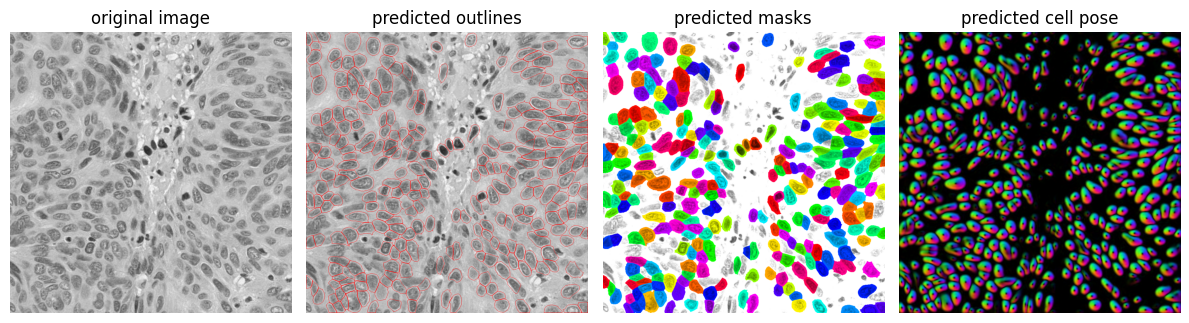

In [28]:
selected_channels = []
for i, c in enumerate([first_channel, second_channel, third_channel]):
  if c == 'None':
    continue
  if int(c) > img.shape[-1]:
    assert False, 'invalid channel index, must have index greater or equal to the number of channels'
  if c != 'None':
    selected_channels.append(int(c))



img_selected_channels = np.zeros_like(img)
img_selected_channels[:, :, :len(selected_channels)] = img[:, :, selected_channels]


flow_threshold = 0.4
cellprob_threshold = -4.0
tile_norm_blocksize = 0

transforms.normalize_img(img, normalize=True, norm3D=True, invert=True, lowhigh=None, percentile=(1.0, 99.0), sharpen_radius=0, smooth_radius=0, tile_norm_blocksize=0, tile_norm_smooth3D=1, axis=-1)

masks, flows, styles = model.eval(img_selected_channels, batch_size=10, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize}, diameter=100)

fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, img_selected_channels, masks, flows[0])
plt.tight_layout()
plt.show()


## Run Cellpose-SAM on folder of images

if you have small images, you may want to load all of them first and then run, so that they can be batched together on the GPU

In [ ]:
# Import output writer utility
from src.io.output_writer import save_masks, save_overlays

In [32]:
# Create output directory if it doesn't exist
output_dir = "/content/cell-fuzzy-seg/data/outputs"
output_dir = Path(output_dir)
if not output_dir.exists():
  output_dir.mkdir(parents=True, exist_ok=True)

In [33]:
print("loading images")
imgs = [data[i]['image'] for i in trange(len(data))]

print("running cellpose-SAM")
masks, flows, styles = model.eval(imgs, batch_size=10, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})
# tentar diminuir o threshold para ver se consegue pegar mais células, mas cuidado para não pegar muito ruído

loading images


100%|██████████| 30/30 [00:13<00:00,  2.29it/s]

running cellpose-SAM
2026-05-03 17:23:36,086 [INFO] 0%|          | 0/30 [00:00<?, ?it/s]


2026-05-03 17:28:19,098 [INFO] 100%|##########| 30/30 [04:43<00:00,  9.43s/it]
saving masks


  0%|          | 0/30 [00:00<?, ?it/s]


KeyError: 'id'

In [ ]:
masks_ext = ".tif"
print("saving masks")
for i in trange(len(data)):
    f = data[i]['id']
    io.imsave(output_dir / (f + "_masks" + masks_ext), masks[i])
    save_masks(output_dir, f, masks[i], ext=masks_ext)
    
    


### Imagem + Máscara

Canais da imagem original: 3


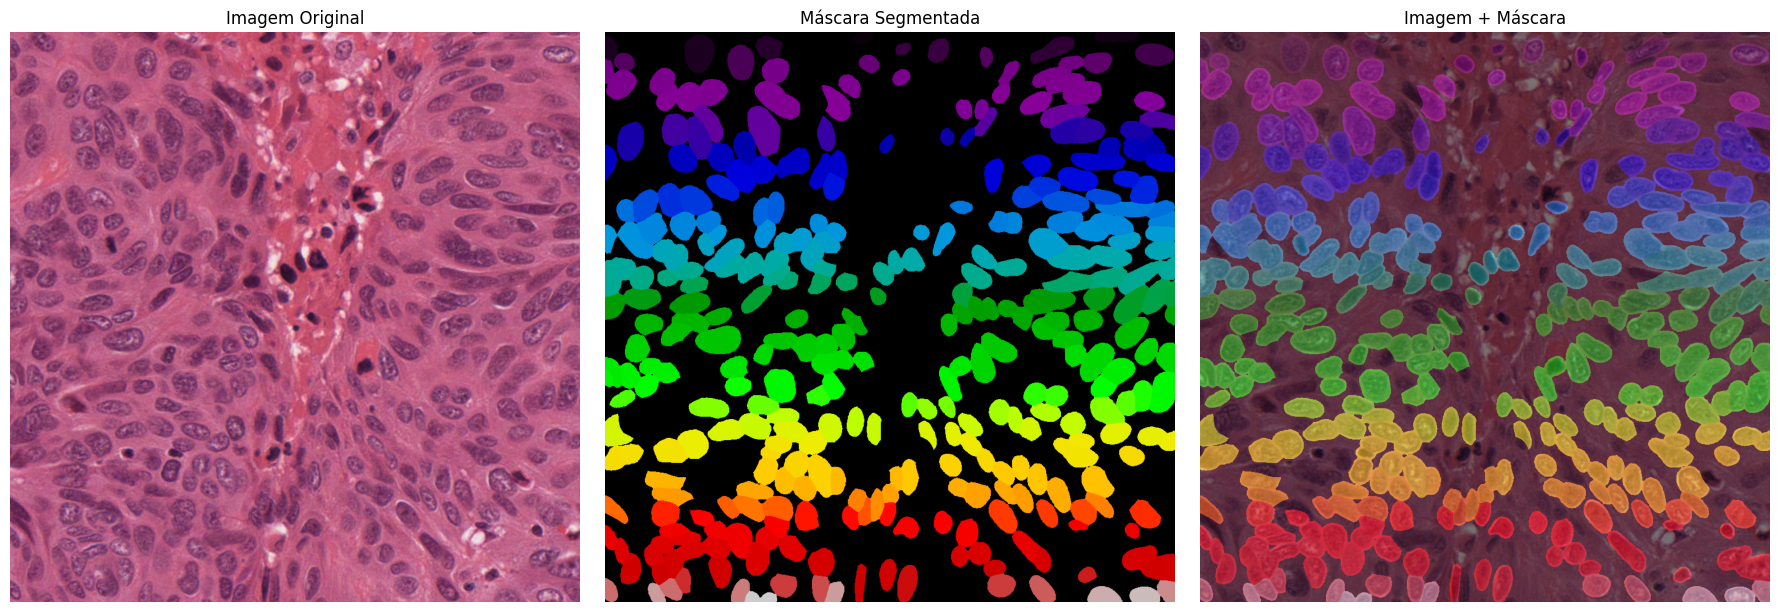

In [ ]:
idx = 0  # Mude isso para o índice da imagem que quer
img_original = imgs[idx]
mask = masks[idx]

print(f"Canais da imagem original: {img_original.shape[-1] if len(img_original.shape) == 3 else 'Imagem em escala de cinza'}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Imagem original
axes[0].imshow(img_original, cmap='gray')
axes[0].set_title('Imagem Original')
axes[0].axis('off')

# Máscara
axes[1].imshow(mask, cmap='nipy_spectral')
axes[1].set_title('Máscara Segmentada')
axes[1].axis('off')

# Sobreposição
axes[2].imshow(img_original, cmap='gray')
axes[2].imshow(mask, cmap='nipy_spectral', alpha=0.5)
axes[2].set_title('Imagem + Máscara')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [12]:
# Diagnóstico dos canais
print(f"Forma da imagem original: {imgs[0].shape}")
print(f"Forma da máscara: {masks[0].shape}")
print(f"Canais selecionados: {selected_channels}")
print(f"Forma de img_selected_channels: {img_selected_channels.shape}")

Forma da imagem original: (1000, 1000, 3)
Forma da máscara: (1000, 1000)
Canais selecionados: [0, 0, 0]
Forma de img_selected_channels: (1000, 1000, 3)


> Read Groud Truth Imagens

In [17]:
truth_dir = Path("/content/cell-fuzzy-seg/data/MoNuSegTrainingData/Annotations")
truth_ext = ".xml"

xml_files = natsorted(truth_dir.glob(f"*{truth_ext}"))

if len(xml_files) == 0:
    raise FileNotFoundError("no XML files found, did you specify the correct folder?")
else:
    print(f"{len(xml_files)} XMLs encontrados:")

for f in xml_files:
    print(f.name)

30 XMLs encontrados:
TCGA-18-5592-01Z-00-DX1.xml
TCGA-21-5784-01Z-00-DX1.xml
TCGA-21-5786-01Z-00-DX1.xml
TCGA-38-6178-01Z-00-DX1.xml
TCGA-49-4488-01Z-00-DX1.xml
TCGA-50-5931-01Z-00-DX1.xml
TCGA-A7-A13E-01Z-00-DX1.xml
TCGA-A7-A13F-01Z-00-DX1.xml
TCGA-AR-A1AK-01Z-00-DX1.xml
TCGA-AR-A1AS-01Z-00-DX1.xml
TCGA-AY-A8YK-01A-01-TS1.xml
TCGA-B0-5698-01Z-00-DX1.xml
TCGA-B0-5710-01Z-00-DX1.xml
TCGA-B0-5711-01Z-00-DX1.xml
TCGA-CH-5767-01Z-00-DX1.xml
TCGA-DK-A2I6-01A-01-TS1.xml
TCGA-E2-A1B5-01Z-00-DX1.xml
TCGA-E2-A14V-01Z-00-DX1.xml
TCGA-G2-A2EK-01A-02-TSB.xml
TCGA-G9-6336-01Z-00-DX1.xml
TCGA-G9-6348-01Z-00-DX1.xml
TCGA-G9-6356-01Z-00-DX1.xml
TCGA-G9-6362-01Z-00-DX1.xml
TCGA-G9-6363-01Z-00-DX1.xml
TCGA-HE-7128-01Z-00-DX1.xml
TCGA-HE-7129-01Z-00-DX1.xml
TCGA-HE-7130-01Z-00-DX1.xml
TCGA-KB-A93J-01A-01-TS1.xml
TCGA-NH-A8F7-01A-01-TS1.xml
TCGA-RD-A8N9-01A-01-TS1.xml


### Salvando input para a próxima rede

In [25]:
for idx in trange(len(files)):
    img_original = imgs[idx]
    mask = masks[idx]
    
    print(f"Processando imagem {files[idx].name} para salvar com 4 canais (RGBA)...")
    print(f"Forma da imagem original: {img_original.shape}")
    print(f"Forma da máscara: {mask.shape}")
    
    # 1. Normalizar imagem original e manter RGB PURO
    img_normalized = (img_original / img_original.max() * 255).astype(np.uint8)
    if len(img_normalized.shape) == 2:
        img_rgb = cv2.cvtColor(img_normalized, cv2.COLOR_GRAY2RGB)
    else:
        img_rgb = img_normalized[:, :, :3]
    
    # 2. Criar o canal Alpha como uma MÁSCARA BINÁRIA (0 ou 255)
    # Isso serve como o "guia espacial" para a rede
    alpha_channel = (mask > 0).astype(np.uint8) * 255
    
    # 3. Concatenar sem fazer "blending" de cores
    # Resultado: Canal 0=R, 1=G, 2=B (puros) e 3=Máscara
    input_rgba = np.dstack([img_rgb, alpha_channel])
    
    print(f"Forma do overlay RGBA: {input_rgba.shape} (Canais: R,G,B,Alpha)")
    
    # Salvar
    img_pil = Image.fromarray(input_rgba)
    img_pil.save(str(output_dir / f"{files[idx].stem}_input_4ch.png"))

  0%|          | 0/30 [00:00<?, ?it/s]

Processando imagem TCGA-18-5592-01Z-00-DX1.tif para salvar com 4 canais (RGBA)...
Forma da imagem original: (1000, 1000, 3)
Forma da máscara: (1000, 1000)
Forma do overlay RGBA: (1000, 1000, 4) (Canais: R,G,B,Alpha)


  3%|▎         | 1/30 [00:00<00:21,  1.33it/s]

Processando imagem TCGA-21-5784-01Z-00-DX1.tif para salvar com 4 canais (RGBA)...
Forma da imagem original: (1000, 1000, 3)
Forma da máscara: (1000, 1000)
Forma do overlay RGBA: (1000, 1000, 4) (Canais: R,G,B,Alpha)


  7%|▋         | 2/30 [00:01<00:19,  1.42it/s]

...

 93%|█████████▎| 28/30 [00:18<00:01,  1.67it/s]

Processando imagem TCGA-NH-A8F7-01A-01-TS1.tif para salvar com 4 canais (RGBA)...
Forma da imagem original: (1000, 1000, 3)
Forma da máscara: (1000, 1000)
Forma do overlay RGBA: (1000, 1000, 4) (Canais: R,G,B,Alpha)


 97%|█████████▋| 29/30 [00:19<00:00,  1.51it/s]

Processando imagem TCGA-RD-A8N9-01A-01-TS1.tif para salvar com 4 canais (RGBA)...
Forma da imagem original: (1000, 1000, 3)
Forma da máscara: (1000, 1000)
Forma do overlay RGBA: (1000, 1000, 4) (Canais: R,G,B,Alpha)


100%|██████████| 30/30 [00:20<00:00,  1.49it/s]



===== TESTE DE INTEGRIDADE: TCGA-18-5592-01Z-00-DX1_input_4ch.png =====
Modo da Imagem (PIL): RGBA
Shape do Array (numpy): (1000, 1000, 4)
Tipo de dado: uint8


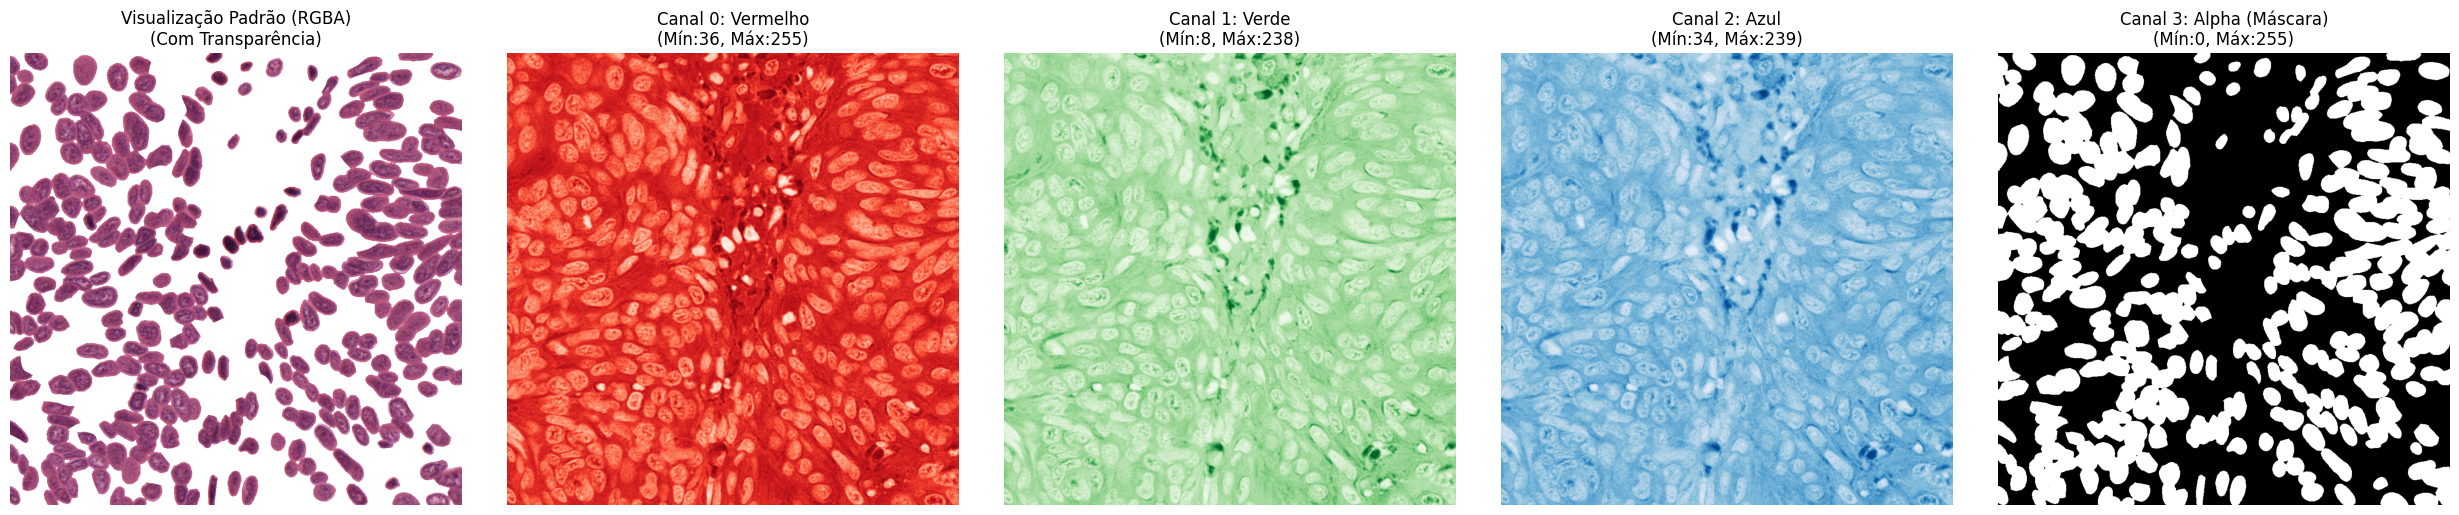

In [26]:
image = "TCGA-18-5592-01Z-00-DX1_input_4ch.png"
caminho_do_arquivo = f"{output_dir}/{image}"

# Verifica se o arquivo existe
if not os.path.exists(caminho_do_arquivo):
    raise FileNotFoundError(f"Arquivo não encontrado: {caminho_do_arquivo}")

# 2. CARREGAR A IMAGEM COMO RGBA
img_rgba = Image.open(caminho_do_arquivo).convert("RGBA")
array_rgba = np.array(img_rgba)

# 3. PROVA REAL (Shape e Tipos)
print(f"\n===== TESTE DE INTEGRIDADE: {os.path.basename(caminho_do_arquivo)} =====")
print(f"Modo da Imagem (PIL): {img_rgba.mode}")
print(f"Shape do Array (numpy): {array_rgba.shape}") # Deve imprimir (H, W, 4)
print(f"Tipo de dado: {array_rgba.dtype}")          # Deve imprimir uint8

# 4. SEPARAR OS CANAIS
# Lembre-se: O numpy trata como (Altura, Largura, Canais)
canal_r = array_rgba[:, :, 0] # Vermelho (Original)
canal_g = array_rgba[:, :, 1] # Verde (Onde você pintou)
canal_b = array_rgba[:, :, 2] # Azul (Original)
canal_a = array_rgba[:, :, 3] # Alpha (MÁSCARA)

# 5. VISUALIZAR USANDO MATPLOTLIB
fig, axes = plt.subplots(1, 5, figsize=(25, 5)) # 1 linha, 5 colunas

# Coluna 1: A imagem completa como o visualizador vê
axes[0].imshow(img_rgba)
axes[0].set_title("Visualização Padrão (RGBA)\n(Com Transparência)")
axes[0].axis('off')

# Coluna 2: Canal Red (como tons de cinza)
axes[1].imshow(canal_r, cmap='Reds')
axes[1].set_title(f"Canal 0: Vermelho\n(Mín:{canal_r.min()}, Máx:{canal_r.max()})")
axes[1].axis('off')

# Coluna 3: Canal Green (como tons de cinza)
axes[2].imshow(canal_g, cmap='Greens')
axes[2].set_title(f"Canal 1: Verde\n(Mín:{canal_g.min()}, Máx:{canal_g.max()})")
axes[2].axis('off')

# Coluna 4: Canal Blue (como tons de cinza)
axes[3].imshow(canal_b, cmap='Blues')
axes[3].set_title(f"Canal 2: Azul\n(Mín:{canal_b.min()}, Máx:{canal_b.max()})")
axes[3].axis('off')

# Coluna 5: O 4º CANAL (ALPHA/MÁSCARA) - Usamos cmap='gray'
axes[4].imshow(canal_a, cmap='gray')
axes[4].set_title(f"Canal 3: Alpha (Máscara)\n(Mín:{canal_a.min()}, Máx:{canal_a.max()})")
axes[4].axis('off')

plt.tight_layout()
plt.show()